# Лабораторная работа №1  
**Тема:** базовые понятия машинного обучения, визуальный анализ данных, бинарная классификация и демонстрация переобучения.

**Что выполнено в работе:**
1. Загружен датасет `iris.zip`.
2. Построен `pairplot` для визуального анализа признаков.
3. Построена модель `LogisticRegression` для бинарной классификации.
4. На синтетических данных показано переобучение линейной регрессии с полиномиальными признаками.


## 1. Импорт библиотек и загрузка данных из `iris.zip`

In [1]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")

zip_path = Path("iris.zip")
extract_dir = Path("data")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df = pd.read_csv(extract_dir / "iris.data", header=None, names=columns).dropna()

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nРаспределение по классам:")
display(df["species"].value_counts())

Размер датасета: (150, 5)

Первые 5 строк:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Распределение по классам:


species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### Вывод  
Датасет Iris содержит **150 объектов** и **4 числовых признака**.  
Классы сбалансированы: по **50 наблюдений** для каждого вида ириса.

## 2. Визуальный анализ данных: `pairplot`

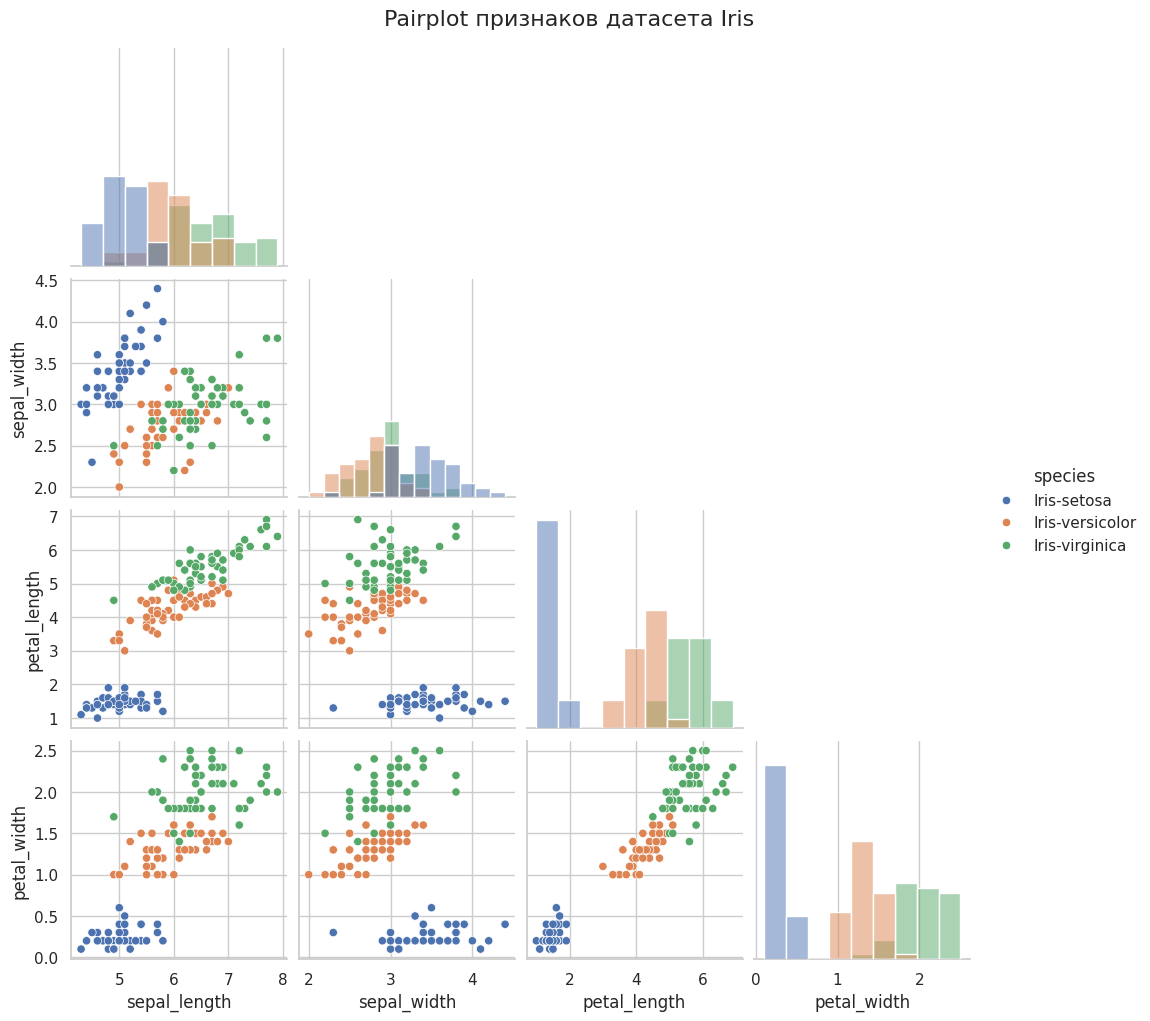

In [2]:
pairplot = sns.pairplot(df, hue="species", corner=True, diag_kind="hist")
pairplot.fig.suptitle("Pairplot признаков датасета Iris", y=1.02, fontsize=16)
plt.show()

### Краткий анализ pairplot  
- **Iris-setosa** хорошо отделяется от двух других классов почти по всем комбинациям признаков.  
- Наиболее информативными выглядят признаки **petal_length** и **petal_width**: по ним разделение классов выражено сильнее всего.  
- Между **Iris-versicolor** и **Iris-virginica** наблюдается частичное пересечение, поэтому задача бинарной классификации остаётся нетривиальной.

## 3. Бинарная классификация с помощью `LogisticRegression`

В качестве положительного класса выберем **Iris-virginica**:
- `1` — объект относится к `Iris-virginica`;
- `0` — объект относится к другим видам.

Для корректной работы логистической регрессии выполним:
1. разбиение на обучающую и тестовую выборки;
2. стандартизацию признаков;
3. обучение модели и оценку метрик качества.


In [3]:
X = df.drop(columns=["species"])
y = (df["species"] == "Iris-virginica").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred = logreg_pipeline.predict(X_test)

metrics_df = pd.DataFrame({
    "Метрика": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Значение": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ]
})
display(metrics_df)

print("Матрица ошибок:")
display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Истинно: не virginica", "Истинно: virginica"],
    columns=["Предсказано: не virginica", "Предсказано: virginica"]
))

print("\nПодробный classification report:")
print(classification_report(y_test, y_pred, digits=3))

,Метрика,Значение
0,Accuracy,0.947368
1,Precision,1.000000
2,Recall,0.846154
3,F1-score,0.916667


Матрица ошибок:


,Предсказано: не virginica,Предсказано: virginica
Истинно: не virginica,25,0
Истинно: virginica,2,11



Подробный classification report:
              precision    recall  f1-score   support

           0      0.926     1.000     0.962        25
           1      1.000     0.846     0.917        13

    accuracy                          0.947        38
   macro avg      0.963     0.923     0.939        38
weighted avg      0.951     0.947     0.946        38



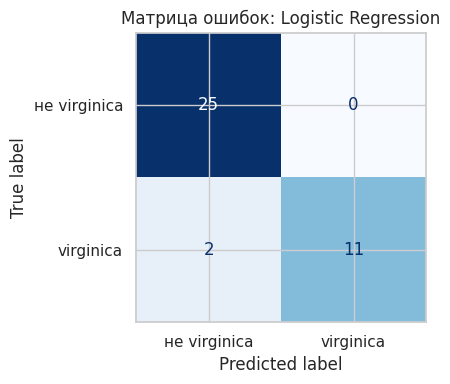

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["не virginica", "virginica"],
    cmap="Blues",
    colorbar=False,
    ax=ax
)
ax.set_title("Матрица ошибок: Logistic Regression")
plt.tight_layout()
plt.show()

In [5]:
coef = pd.Series(
    logreg_pipeline.named_steps["model"].coef_[0],
    index=X.columns
).sort_values(key=np.abs, ascending=False)

coef_df = coef.reset_index()
coef_df.columns = ["Признак", "Коэффициент"]
display(coef_df)

,Признак,Коэффициент
0,petal_width,2.730595
1,petal_length,1.983201
2,sepal_length,0.529423
3,sepal_width,-0.386122


### Вывод по бинарной классификации  
Модель показала высокое качество:
- `Accuracy ≈ 0.947`
- `F1-score ≈ 0.917`

Самыми важными признаками оказались **petal_width** и **petal_length**, что согласуется с визуальным анализом `pairplot`.  
Это означает, что размеры лепестка лучше всего помогают отличить `Iris-virginica` от остальных классов.

## 4. Демонстрация переобучения линейной регрессии

Чтобы наглядно показать переобучение, сгенерируем синтетические данные:
- истинная зависимость: `y = sin(2πx) + шум`;
- далее обучим **линейную регрессию** на полиномиальных признаках разных степеней.

Важно: модель по-прежнему остаётся **линейной регрессией по параметрам**, но пространство признаков расширяется с помощью `PolynomialFeatures`.  
При слишком высокой степени полинома модель начинает подстраиваться под шум обучающей выборки, что и является переобучением.


In [6]:
rng = np.random.default_rng(42)

n = 30
X_syn = np.sort(rng.uniform(0, 1, size=n))
y_syn = np.sin(2 * np.pi * X_syn) + rng.normal(0, 0.15, size=n)

X_syn = X_syn.reshape(-1, 1)

X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.4, random_state=42
)

degrees = [1, 2, 3, 5, 7, 10, 15, 20]
rows = []

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    model.fit(X_train_syn, y_train_syn)

    train_pred = model.predict(X_train_syn)
    test_pred = model.predict(X_test_syn)

    rows.append({
        "Степень полинома": degree,
        "Train MSE": mean_squared_error(y_train_syn, train_pred),
        "Test MSE": mean_squared_error(y_test_syn, test_pred),
        "Train R²": r2_score(y_train_syn, train_pred),
        "Test R²": r2_score(y_test_syn, test_pred),
    })

overfit_df = pd.DataFrame(rows)
display(overfit_df.round(6))

,Степень полинома,Train MSE,Test MSE,Train R²,Test R²
0,1,0.184662,0.173836,0.668832,6.101770e-01
1,2,0.183484,0.164432,0.670944,6.312670e-01
2,3,0.007876,0.038483,0.985876,9.137040e-01
3,5,0.007642,0.033266,0.986295,9.254030e-01
4,7,0.007425,0.027554,0.986683,9.382120e-01
5,10,0.004567,0.020471,0.991810,9.540950e-01
6,15,0.000983,401.118566,0.998237,-8.984972e+02
7,20,0.000033,622492.045302,0.999941,-1.395920e+06


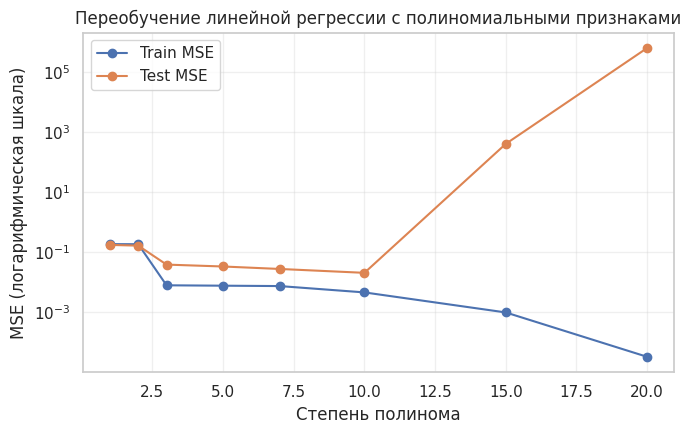

In [7]:
plt.figure(figsize=(7, 4.5))
plt.plot(overfit_df["Степень полинома"], overfit_df["Train MSE"], marker="o", label="Train MSE")
plt.plot(overfit_df["Степень полинома"], overfit_df["Test MSE"], marker="o", label="Test MSE")
plt.yscale("log")
plt.xlabel("Степень полинома")
plt.ylabel("MSE (логарифмическая шкала)")
plt.title("Переобучение линейной регрессии с полиномиальными признаками")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

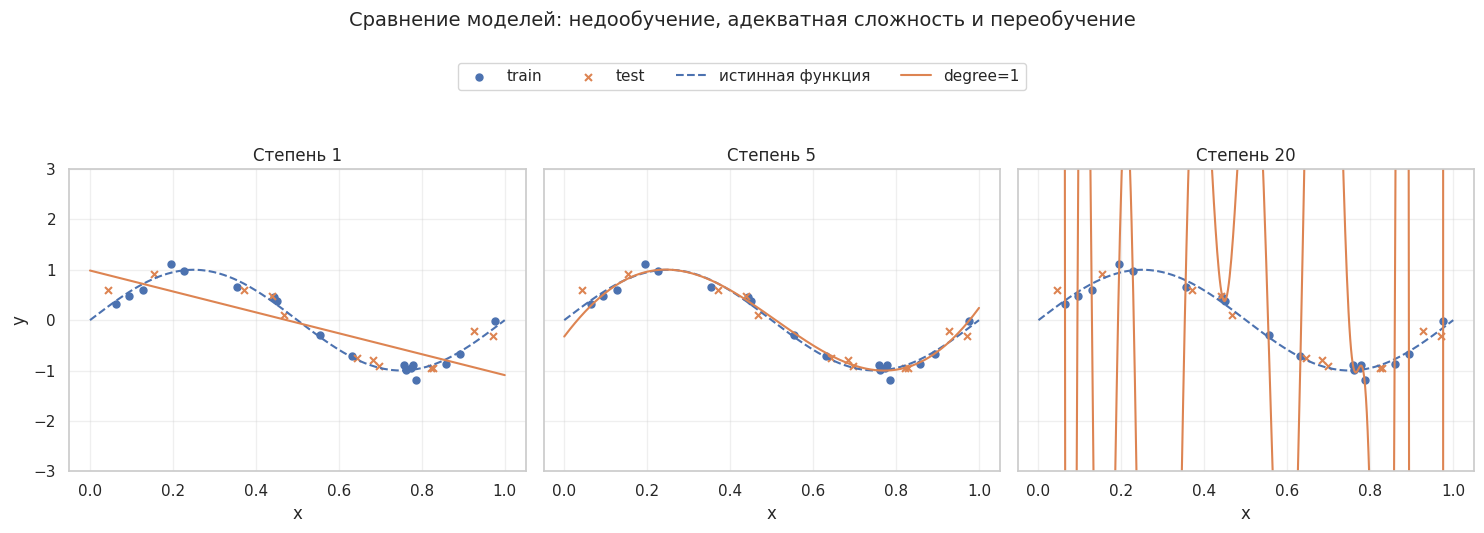

In [8]:
x_grid = np.linspace(0, 1, 500).reshape(-1, 1)
y_true = np.sin(2 * np.pi * x_grid).ravel()

degrees_show = [1, 5, 20]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, degree in zip(axes, degrees_show):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    model.fit(X_train_syn, y_train_syn)
    y_grid = model.predict(x_grid)

    ax.scatter(X_train_syn, y_train_syn, label="train", s=25)
    ax.scatter(X_test_syn, y_test_syn, label="test", s=25, marker="x")
    ax.plot(x_grid, y_true, linestyle="--", label="истинная функция")
    ax.plot(x_grid, y_grid, label=f"degree={degree}")
    ax.set_title(f"Степень {degree}")
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("y")
axes[0].set_ylim(-3, 3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Сравнение моделей: недообучение, адекватная сложность и переобучение", y=1.18, fontsize=14)
plt.tight_layout()
plt.show()

### Вывод по переобучению  
- При малой степени полинома модель слишком простая и **недообучается**.  
- При умеренной степени модель хорошо описывает зависимость и показывает низкую ошибку на тесте.  
- При высокой степени полинома ошибка на обучении почти исчезает, но ошибка на тесте резко возрастает.  
Это и есть **переобучение**: модель слишком точно запоминает обучающую выборку и хуже обобщает новые данные.

## 5. Ответы на теоретические вопросы

### 5.1. В чём состоит основная проблема переобучения?  
Переобучение возникает тогда, когда модель слишком сильно подстраивается под обучающие данные, включая случайный шум и частные особенности выборки.  
В результате на обучающем наборе модель работает отлично, а на новых данных её качество ухудшается.

### 5.2. Почему нельзя оценивать качество модели на тех данных, на которых она обучалась?  
Потому что в таком случае мы измеряем не способность модели **обобщать**, а её способность **запоминать** уже увиденные примеры.  
Оценка на обучающей выборке почти всегда оказывается слишком оптимистичной и не отражает реальное качество модели на новых данных.

### 5.3. Что такое регуляризация и как она помогает бороться со сложностью модели?  
Регуляризация — это добавление штрафа за слишком большие коэффициенты или чрезмерную сложность модели.  
Она ограничивает гибкость модели, снижает риск подстройки под шум и помогает улучшить качество обобщения на тестовых данных.

## 6. Итоговый вывод  
В работе были освоены базовые этапы анализа данных:
- загрузка и первичная обработка датасета;
- визуальное исследование признаков;
- построение модели бинарной классификации;
- анализ явления переобучения на примере линейной регрессии.

Практический эксперимент показал, что:
- признаки лепестка являются наиболее информативными для классификации объектов Iris;
- логистическая регрессия обеспечивает высокое качество при корректной подготовке признаков;
- чрезмерное усложнение модели приводит к переобучению и росту ошибки на новых данных.
